<a href="https://colab.research.google.com/github/anikaBushra81/Artificial_Intelligence_Lab/blob/main/Earthquack3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE


df = pd.read_csv("earthquakes (1).csv")

print("Shape:", df.shape)
print("Columns:", df.columns)

Shape: (1137, 43)
Columns: Index(['id', 'magnitude', 'type', 'title', 'date', 'time', 'updated', 'url',
       'detailUrl', 'felt', 'cdi', 'mmi', 'alert', 'status', 'tsunami', 'sig',
       'net', 'code', 'ids', 'sources', 'types', 'nst', 'dmin', 'rms', 'gap',
       'magType', 'geometryType', 'depth', 'latitude', 'longitude', 'place',
       'distanceKM', 'placeOnly', 'location', 'continent', 'country',
       'subnational', 'city', 'locality', 'postcode', 'what3words', 'timezone',
       'locationDetails'],
      dtype='object')


In [4]:
# Significant earthquake label (>= 5.0)
df['label_sig'] = (df['magnitude'] >= 5.0).astype(int)

# Drop unused columns
drop_cols = ['id','title','url','locationDetails','what3words']
for col in drop_cols:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# Features / Target
X = df.drop(columns=['magnitude','label_sig'])
y = df['label_sig']


In [5]:

# Separate categorical & numeric
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

# Impute
num_imputer = SimpleImputer(strategy="median")
X_num = pd.DataFrame(num_imputer.fit_transform(X[num_cols]), columns=num_cols)

if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    X_cat = pd.DataFrame(cat_imputer.fit_transform(X[cat_cols]), columns=cat_cols)
    X_cat = pd.get_dummies(X_cat, drop_first=True)
    X_proc = pd.concat([X_num, X_cat], axis=1)
else:
    X_proc = X_num.copy()

print("Final Feature Shape:", X_proc.shape)


Final Feature Shape: (1137, 4235)



Pearson Correlation with magnitude:
 longitude     0.746729
timezone      0.730700
sig           0.717398
nst           0.666889
rms           0.600094
dmin          0.527240
mmi           0.444663
cdi           0.331727
depth         0.310034
tsunami       0.226943
distanceKM    0.097969
felt         -0.007569
postcode     -0.133547
gap          -0.245491
latitude     -0.410561
updated      -0.498503
time         -0.574277
dtype: float64


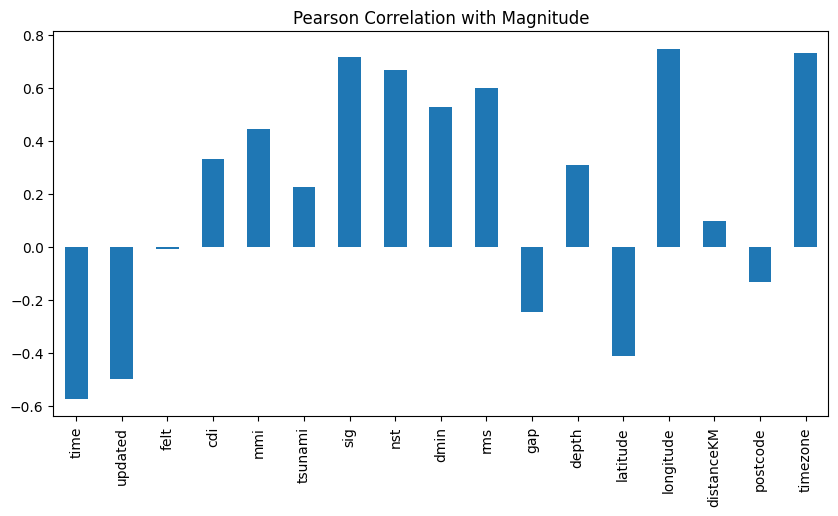

In [6]:
#Pearson Correlation
pearson_corr = X_num.corrwith(df['magnitude'])
print("\nPearson Correlation with magnitude:\n", pearson_corr.sort_values(ascending=False))
pearson_corr.plot(kind='bar', figsize=(10,5), title="Pearson Correlation with Magnitude")
plt.show()



Information Gain Scores:
 sig                        0.573306
longitude                  0.552189
latitude                   0.543678
timezone                   0.457330
dmin                       0.445467
time                       0.442938
updated                    0.442127
nst                        0.402527
magType_mww                0.376852
depth                      0.366538
magType_ml                 0.320776
rms                        0.288455
net_us                     0.283721
continent_North America    0.267017
distanceKM                 0.226642
dtype: float64


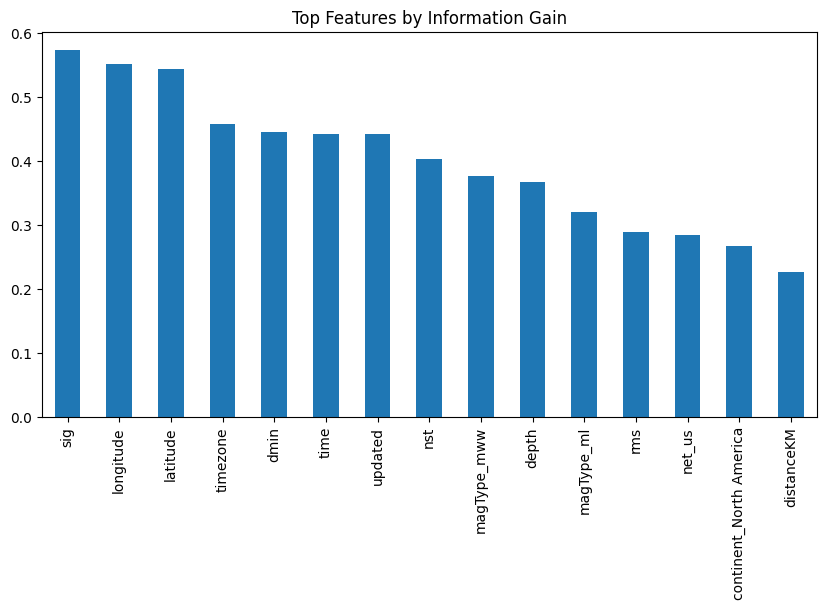

In [7]:
#Information Gain
mi_scores = mutual_info_classif(X_proc, y)
mi_series = pd.Series(mi_scores, index=X_proc.columns).sort_values(ascending=False)
print("\nInformation Gain Scores:\n", mi_series.head(15))

mi_series.head(15).plot(kind='bar', figsize=(10,5), title="Top Features by Information Gain")
plt.show()



Gain Ratio (approx):
 sig                        1.000000
longitude                  0.963165
latitude                   0.948320
timezone                   0.797706
dmin                       0.777014
time                       0.772603
updated                    0.771188
nst                        0.702115
magType_mww                0.657332
depth                      0.639340
magType_ml                 0.559519
rms                        0.503143
net_us                     0.494885
continent_North America    0.465749
distanceKM                 0.395324
dtype: float64


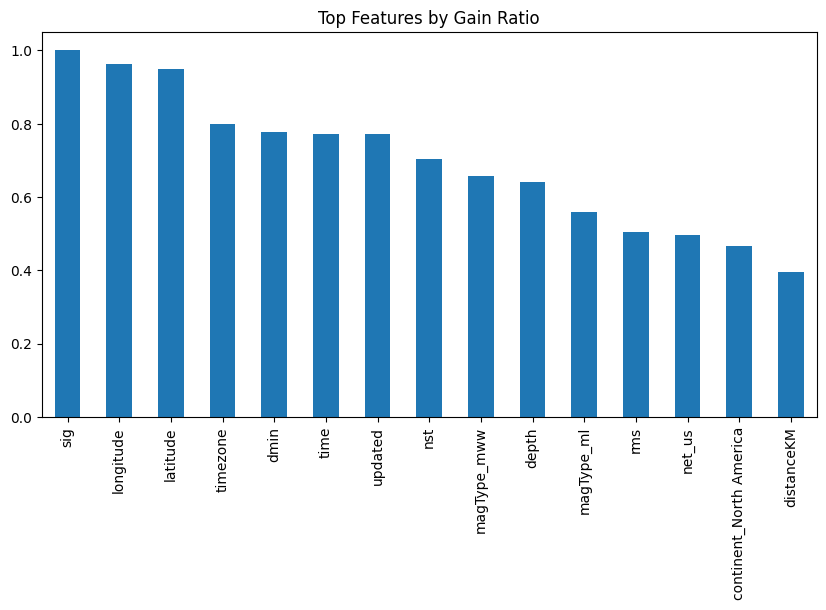

In [8]:
#Gain Ratio
scaler = MinMaxScaler()
gain_ratio = scaler.fit_transform(mi_scores.reshape(-1,1)).flatten()
gain_ratio_series = pd.Series(gain_ratio, index=X_proc.columns).sort_values(ascending=False)
print("\nGain Ratio (approx):\n", gain_ratio_series.head(15))

gain_ratio_series.head(15).plot(kind='bar', figsize=(10,5), title="Top Features by Gain Ratio")
plt.show()



Hybrid Feature Scores:
 longitude     0.981582
sig           0.980159
timezone      0.888010
nst           0.797050
time          0.769648
latitude      0.746761
dmin          0.740035
updated       0.717684
rms           0.652381
depth         0.524271
mmi           0.360094
gap           0.332351
cdi           0.269287
distanceKM    0.258813
postcode      0.196714
dtype: float64


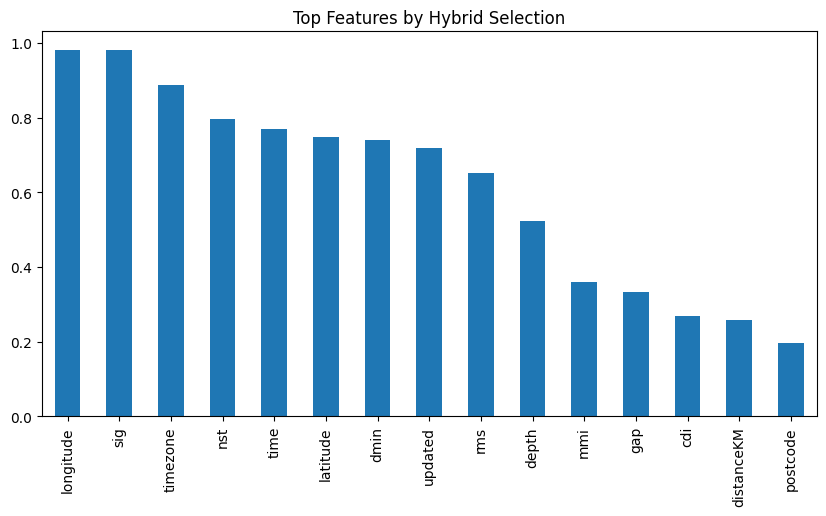

In [9]:
#Hybrid Feature

# Normalize Pearson + MI
pearson_norm = scaler.fit_transform(abs(pearson_corr.fillna(0)).values.reshape(-1,1)).flatten()
mi_norm = scaler.fit_transform(mi_scores.reshape(-1,1)).flatten()

# Align Pearson index with X_proc
pearson_series = pd.Series(pearson_norm, index=X_num.columns)
mi_series_full = pd.Series(mi_norm, index=X_proc.columns)

# For hybrid, only common features
common_features = list(set(X_num.columns) & set(X_proc.columns))

hybrid_scores = (pearson_series[common_features] + mi_series_full[common_features]) / 2
hybrid_scores = hybrid_scores.sort_values(ascending=False)

print("\nHybrid Feature Scores:\n", hybrid_scores.head(15))

hybrid_scores.head(15).plot(kind='bar', figsize=(10,5), title="Top Features by Hybrid Selection")
plt.show()


In [10]:
#Select top-n feature

top_features = hybrid_scores.head(10).index.tolist()
X_selected = X_proc[top_features]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)

# Handle imbalance
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)

# Scale
scaler_final = StandardScaler(with_mean=False)
X_train_s = scaler_final.fit_transform(X_train)
X_test_s = scaler_final.transform(X_test)


In [11]:
#Model and Evaluation

models = {
    "LogReg": LogisticRegression(max_iter=1000, random_state=42),
    "RF": RandomForestClassifier(n_estimators=300, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "XGB": XGBClassifier(n_estimators=300, learning_rate=0.05, random_state=42, eval_metric='logloss')
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    results[name] = {"ACC": acc, "PREC": prec, "REC": rec, "F1": f1}
    print(f"{name}: ACC={acc:.3f}, PREC={prec:.3f}, REC={rec:.3f}, F1={f1:.3f}")


LogReg: ACC=0.947, PREC=0.968, REC=0.938, F1=0.953
RF: ACC=0.996, PREC=0.992, REC=1.000, F1=0.996
SVM: ACC=0.886, PREC=0.973, REC=0.823, F1=0.892
XGB: ACC=0.996, PREC=0.992, REC=1.000, F1=0.996


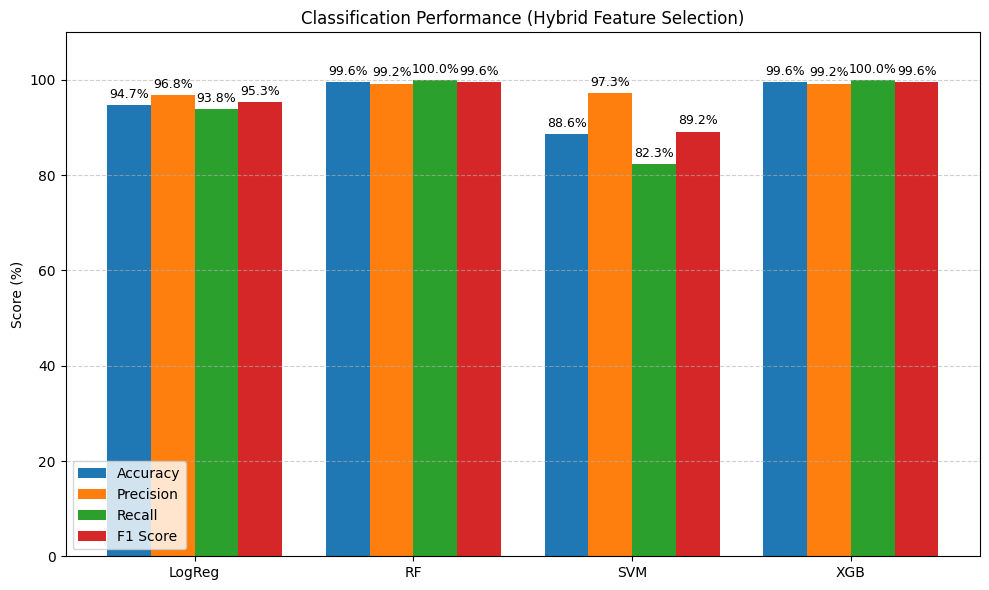

In [12]:
#Graph


labels = list(results.keys())
acc = [results[m]['ACC']*100 for m in labels]
prec = [results[m]['PREC']*100 for m in labels]
rec = [results[m]['REC']*100 for m in labels]
f1 = [results[m]['F1']*100 for m in labels]

x = np.arange(len(labels))
width = 0.2

plt.figure(figsize=(10,6))
rects1 = plt.bar(x - 1.5*width, acc, width, label='Accuracy')
rects2 = plt.bar(x - 0.5*width, prec, width, label='Precision')
rects3 = plt.bar(x + 0.5*width, rec, width, label='Recall')
rects4 = plt.bar(x + 1.5*width, f1, width, label='F1 Score')

plt.xticks(x, labels)
plt.ylabel("Score (%)")
plt.title("Classification Performance (Hybrid Feature Selection)")
plt.legend()
plt.ylim(0, 110)


def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        plt.annotate(f'{height:.1f}%',
                     xy=(rect.get_x() + rect.get_width()/2, height),
                     xytext=(0,3),
                     textcoords="offset points",
                     ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


In [15]:
# Train_all_ML_models and 1 DL model

# Imports
import joblib, os, numpy as np, pandas as pd
from time import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# --- (ASSUME these exist from prior cells) ---
# X_train_s, X_test_s, y_train, y_test, top_features, scaler_final

# Classical models dict
models = {
    "LogReg": LogisticRegression(max_iter=2000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "DT": DecisionTreeClassifier(random_state=42),
    "RF": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "ET": ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "GB": GradientBoostingClassifier(random_state=42),
    "ADA": AdaBoostClassifier(random_state=42),
    "XGB": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_estimators=200),
    "LGBM": LGBMClassifier(n_estimators=200, random_state=42),
    "CAT": CatBoostClassifier(verbose=0, random_state=42)
}

results = {}
trained_models = {}

for name, model in models.items():
    t0 = time()
    model.fit(X_train_s, y_train)
    t1 = time()
    preds = model.predict(X_test_s)
    probs = None
    try:
        probs = model.predict_proba(X_test_s)[:,1]
    except:
        pass
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, zero_division=0)
    rec = recall_score(y_test, preds, zero_division=0)
    f1 = f1_score(y_test, preds, zero_division=0)
    auc = roc_auc_score(y_test, probs) if probs is not None else np.nan
    results[name] = {"ACC": acc, "PREC": prec, "REC": rec, "F1": f1, "AUC": auc, "time_s": t1-t0}
    trained_models[name] = model
    print(f"{name}: ACC={acc:.3f}, PREC={prec:.3f}, REC={rec:.3f}, F1={f1:.3f}, AUC={auc if not np.isnan(auc) else 'NA'}")


LogReg: ACC=0.947, PREC=0.968, REC=0.938, F1=0.953, AUC=0.9851648351648352
KNN: ACC=0.947, PREC=0.976, REC=0.931, F1=0.953, AUC=0.9904631083202512
DT: ACC=1.000, PREC=1.000, REC=1.000, F1=1.000, AUC=1.0
RF: ACC=0.996, PREC=0.992, REC=1.000, F1=0.996, AUC=0.9999999999999999
ET: ACC=0.991, PREC=0.992, REC=0.992, F1=0.992, AUC=0.9992935635792779
GB: ACC=0.996, PREC=0.992, REC=1.000, F1=0.996, AUC=0.9997645211930926
ADA: ACC=0.996, PREC=0.992, REC=1.000, F1=0.996, AUC=0.9992935635792778


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [03:43:06] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB: ACC=0.996, PREC=0.992, REC=1.000, F1=0.996, AUC=0.9990580847723705
[LightGBM] [Info] Number of positive: 519, number of negative: 519
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000207 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2139
[LightGBM] [Info] Number of data points in the train set: 1038, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


CAT: ACC=0.996, PREC=0.992, REC=1.000, F1=0.996, AUC=0.9999215070643642


In [14]:
%pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.8 MB/s eta 0:00:00


In [16]:
#Train a simple Keras (DL) model (ML er sathe compare korar jonno)

# Simple MLP for tabular classification
input_dim = X_train_s.shape[1]
def build_mlp(input_dim):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
    return model

keras_model = build_mlp(input_dim)
es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
ckpt_path = 'artifacts/keras_best.h5'
os.makedirs('artifacts', exist_ok=True)
ckpt = ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True)

history = keras_model.fit(
    X_train_s, y_train,
    validation_split=0.15,
    epochs=200,
    batch_size=32,
    callbacks=[es, ckpt],
    verbose=1
)

# evaluate
keras_model.load_weights(ckpt_path)
probs = keras_model.predict(X_test_s).ravel()
preds = (probs >= 0.5).astype(int)
acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds, zero_division=0)
rec = recall_score(y_test, preds, zero_division=0)
f1 = f1_score(y_test, preds, zero_division=0)
auc = roc_auc_score(y_test, probs)
results['Keras_MLP'] = {"ACC": acc, "PREC": prec, "REC": rec, "F1": f1, "AUC": auc}
trained_models['Keras_MLP'] = keras_model
print("Keras_MLP:", results['Keras_MLP'])


Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.7330 - loss: 0.6139

28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - AUC: 0.7456 - loss: 0.5969 - val_AUC: 0.5000 - val_loss: 5.8829
Epoch 2/200
25/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.9817 - loss: 0.1384 

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.9821 - loss: 0.1380 - val_AUC: 0.5000 - val_loss: 4.3183
Epoch 3/200
 1/28 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - AUC: 1.0000 - loss: 0.0329

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.9896 - loss: 0.0956 - val_AUC: 0.5000 - val_loss: 3.6527
Epoch 4/200
 1/28 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - AUC: 1.0000 - loss: 0.0259

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.9857 - loss: 0.1266 - val_AUC: 0.5000 - val_loss: 2.4004
Epoch 5/200
24/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.9833 - loss: 0.1360 

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.9833 - loss: 0.1365 - val_AUC: 0.5000 - val_loss: 1.9543
Epoch 6/200
 1/28 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - AUC: 0.9804 - loss: 0.1656

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.9816 - loss: 0.1455 - val_AUC: 0.5000 - val_loss: 1.3650
Epoch 7/200
 1/28 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - AUC: 0.9659 - loss: 0.2849

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.9886 - loss: 0.1142 - val_AUC: 0.5000 - val_loss: 1.2972
Epoch 8/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.9682 - loss: 0.1934 

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.9687 - loss: 0.1915 - val_AUC: 0.5333 - val_loss: 0.9319
Epoch 9/200
 1/28 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - AUC: 0.9903 - loss: 0.1564

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.9798 - loss: 0.1547 - val_AUC: 0.7953 - val_loss: 0.4175
Epoch 10/200
26/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.9880 - loss: 0.1038 

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.9876 - loss: 0.1064 - val_AUC: 0.9849 - val_loss: 0.1648
Epoch 11/200
26/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.9818 - loss: 0.1604 

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.9823 - loss: 0.1576 - val_AUC: 0.9846 - val_loss: 0.1617
Epoch 12/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.9870 - loss: 0.1311 - val_AUC: 0.9603 - val_loss: 0.2337
Epoch 13/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.9880 - loss: 0.1192 - val_AUC: 0.9525 - val_loss: 0.1861
Epoch 14/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.9861 - loss: 0.1225 - val_AUC: 0.9605 - val_loss: 0.2477
Epoch 15/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.9893 - loss: 0.1147 - val_AUC: 0.8955 - val_loss: 0.2785
Epoch 16/200
26/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.9854 - loss: 0.1114 

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - AUC: 0.9854 - loss: 0.1121 - val_AUC: 0.9898 - val_loss: 0.0823
Epoch 17/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.9944 - loss: 0.0885 - val_AUC: 0.9626 - val_loss: 0.2649
Epoch 18/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.9921 - loss: 0.1005 - val_AUC: 0.6979 - val_loss: 0.5648
Epoch 19/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.9920 - loss: 0.0982 - val_AUC: 0.9915 - val_loss: 0.0946
Epoch 20/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.9890 - loss: 0.1225 - val_AUC: 0.9801 - val_loss: 0.1805
Epoch 21/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - AUC: 0.9821 - loss: 0.1333 - val_AUC: 0.6948 - val_loss: 0.5498
Epoch 22/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.9924 - loss: 0.0943 - val_AUC: 0.9657 - val_loss: 0.1526
Epoch 23/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.9910 - loss: 0.1197 - val_AUC: 0.9681 - val_loss: 1.9439
Epoch 24/200
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - AUC: 0.9944 - l

In [18]:
# Compare results and choose best model (use F1 or AUC)

import pandas as pd
res_df = pd.DataFrame(results).T
res_df = res_df.sort_values(by='F1', ascending=False)
display(res_df)
best_name = res_df.index[0]
best_name, res_df.iloc[0].to_dict()


,ACC,PREC,REC,F1,AUC,time_s
DT,1.000000,1.000000,1.000000,1.000000,1.000000,0.005471
GB,0.995614,0.992366,1.000000,0.996169,0.999765,0.354817
RF,0.995614,0.992366,1.000000,0.996169,1.000000,0.500115
CAT,0.995614,0.992366,1.000000,0.996169,0.999922,2.264640
LGBM,0.995614,0.992366,1.000000,0.996169,0.999294,0.156455
ADA,0.995614,0.992366,1.000000,0.996169,0.999294,0.142372
XGB,0.995614,0.992366,1.000000,0.996169,0.999058,0.061870
ET,0.991228,0.992308,0.992308,0.992308,0.999294,0.301041
LogReg,0.947368,0.968254,0.938462,0.953125,0.985165,0.045300
KNN,0.947368,0.975806,0.930769,0.952756,0.990463,0.007451


('DT',
 {'ACC': 1.0,
  'PREC': 1.0,
  'REC': 1.0,
  'F1': 1.0,
  'AUC': 1.0,
  'time_s': 0.0054705142974853516})

In [19]:
# Save best model + scaler (artifact)

# ensure artifacts dir
os.makedirs('artifacts', exist_ok=True)

best_name = res_df.index[0]
best_model = trained_models[best_name]

# save scaler (so deploy can scale input)
joblib.dump(scaler_final, 'artifacts/scaler_final.joblib')

if best_name == 'Keras_MLP':
    best_model.save('artifacts/best_model_keras.h5')
else:
    joblib.dump(best_model, 'artifacts/best_model.pkl')

# save the feature order (top_features) to ensure deployment uses same order
joblib.dump(top_features, 'artifacts/top_features.joblib')

print("Saved:", best_name)


Saved: DT


  0%|          | 0/50 [00:00<?, ?it/s]

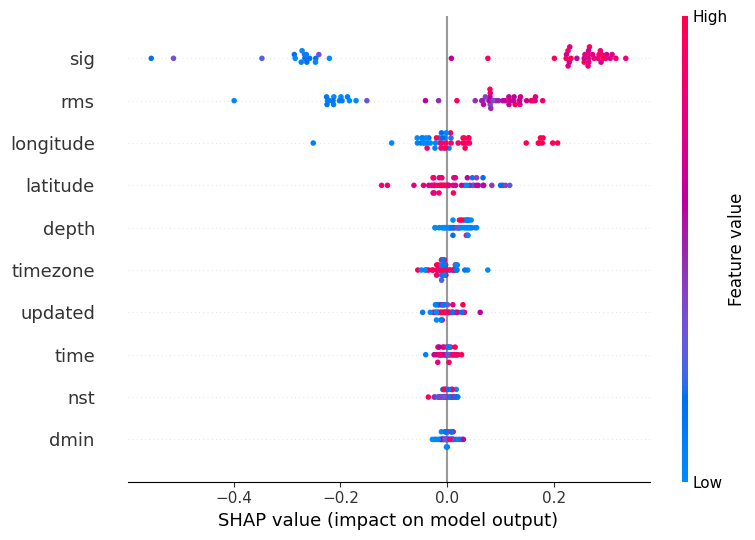

In [20]:
# XAI: SHAP (global + local)

import shap
import pandas as pd
# Load best model if needed
# best_model = joblib.load('artifacts/best_model.pkl')  # if restarting kernel

# prepare a DataFrame view of test (with feature names)
X_test_df = pd.DataFrame(X_test_s, columns=top_features)

if best_name in ['RF','XGB','LGBM','CAT','ET','GB']:
    explainer = shap.TreeExplainer(best_model)
    # compute shap values for a subset (speed)
    sv = explainer.shap_values(X_test_df.iloc[:200])
    shap.summary_plot(sv, X_test_df.iloc[:200], feature_names=top_features, show=True)
else:
    # fallback (slow)
    background = X_train_s[np.random.choice(X_train_s.shape[0], 100, replace=False)]
    explainer = shap.KernelExplainer(lambda x: best_model.predict_proba(x)[:,1], background)
    sv = explainer.shap_values(X_test_s[:50], nsamples=100)
    shap.summary_plot(sv, pd.DataFrame(X_test_s[:50], columns=top_features))


In [21]:
# Local explanation (one sample):

idx = 3
shap.initjs()
if isinstance(sv, list):
    svals = sv[1] if len(sv)>1 else sv[0]
else:
    svals = sv
shap.force_plot(explainer.expected_value if hasattr(explainer,'expected_value') else explainer.base_value, svals[idx], pd.DataFrame(X_test_s[:200], columns=top_features).iloc[idx,:])


In [24]:
# XAI: LIME (local explanations)

from lime.lime_tabular import LimeTabularExplainer

# For LIME use scaled data (because model expects scaled input)
explainer_lime = LimeTabularExplainer(
    training_data=np.array(X_train_s),
    feature_names=top_features,
    class_names=['not_sig','sig'],
    mode='classification'
)

i = 5  # test sample index
if hasattr(best_model, 'predict_proba'):
    predict_fn = lambda x: best_model.predict_proba(x)
else:
    # wrapper for keras model if needed
    predict_fn = lambda x: np.vstack([1-best_model.predict(x).ravel(), best_model.predict(x).ravel()]).T

exp = explainer_lime.explain_instance(
    X_test_s[i],
    predict_fn,
    num_features=min(10, len(top_features))
)
print(exp.as_list())
exp.save_to_file('artifacts/lime_explanation.html')


[('0.85 < sig <= 1.70', -0.3595792957564369), ('rms > 2.48', 0.17725773321541924), ('latitude <= 1.38', 0.13066847034282378), ('-0.83 < longitude <= 1.06', 0.05150947204113592), ('0.08 < depth <= 0.12', 0.04294813305221056), ('0.37 < nst <= 1.03', -0.013448185585821967), ('180.55 < updated <= 181.82', 0.01230902189538321), ('0.06 < dmin <= 0.31', 0.010619838654422982), ('-0.69 < timezone <= 1.10', -0.009665901048288662), ('150.18 < time <= 151.19', 0.00047830981521350765)]


In [25]:
%pip install lime

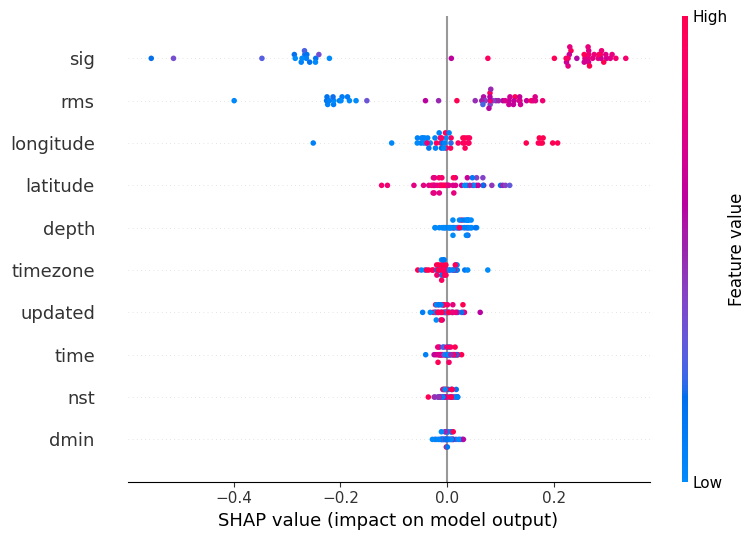

In [28]:
plt.figure(figsize=(8,6))

# Check if SHAP values are a list (multi-output models)
if isinstance(sv, list):
    sv_to_plot = sv[1] if len(sv) > 1 else sv[0]
else:
    sv_to_plot = sv

# Automatically match feature rows to SHAP values
n_rows = sv_to_plot.shape[0]
X_test_subset = X_test_df.iloc[:n_rows]   # ✅ same number of rows

# Create summary plot
shap.summary_plot(sv_to_plot, X_test_subset, show=False)
plt.savefig('artifacts/shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()


In [29]:
shap.force_plot(explainer.expected_value, svals[0], X_test_df.iloc[0,:], matplotlib=False, show=False)
shap.save_html('artifacts/shap_force_0.html', shap.force_plot(explainer.expected_value, svals[0], X_test_df.iloc[0,:]))
